### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



- Faturamento da Loja 1: R$ 1,534,509.12

- Faturamento da Loja 2: R$ 1,488,459.06

- Faturamento da Loja 3: R$ 1,464,025.03

- Faturamento da Loja 4: R$ 1,384,497.58



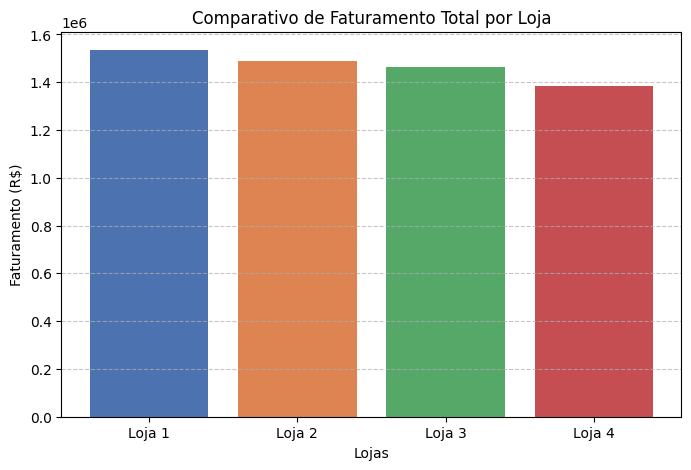

In [2]:

import matplotlib.pyplot as plt

# agrupar lojas em uma lista
lista_lojas = [
    ('Loja 1', loja),
    ('Loja 2', loja2),
    ('Loja 3', loja3),
    ('Loja 4', loja4)
]

# dicionário para guardar o faturamento de cada loja
faturamentos = {}

# calcular o faturamento de cada loja
for nome, df in lista_lojas:
    # somando todos os valores da coluna
    faturamento_total = df['Preço'].sum()

    faturamentos[nome] = faturamento_total
    print(f"- Faturamento da {nome}: R$ {faturamento_total:,.2f}\n")

# gráfico de barras do faturamento
nomes_lojas = list(faturamentos.keys())
valores_faturamento = list(faturamentos.values())

plt.figure(figsize=(8, 5))
plt.bar(nomes_lojas, valores_faturamento, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Comparativo de Faturamento Total por Loja')
plt.ylabel('Faturamento (R$)')
plt.xlabel('Lojas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Vendas por Categoria

In [3]:
for nome, df in lista_lojas:
    print(f"🏆 === {nome}: Categorias mais Populares ===\n")

    # contagem de vezes que cada categoria vende
    vendas_categoria = df['Categoria do Produto'].value_counts()

    print(vendas_categoria.to_string()) # o .to_string(), para não aparecer o tipo de dado que está sendo usado
    print("-" * 40, "\n")

🏆 === Loja 1: Categorias mais Populares ===

Categoria do Produto
moveis                   465
eletronicos              448
brinquedos               324
eletrodomesticos         312
esporte e lazer          284
instrumentos musicais    182
livros                   173
utilidades domesticas    171
---------------------------------------- 

🏆 === Loja 2: Categorias mais Populares ===

Categoria do Produto
moveis                   442
eletronicos              422
brinquedos               313
eletrodomesticos         305
esporte e lazer          275
instrumentos musicais    224
livros                   197
utilidades domesticas    181
---------------------------------------- 

🏆 === Loja 3: Categorias mais Populares ===

Categoria do Produto
moveis                   499
eletronicos              451
brinquedos               315
eletrodomesticos         278
esporte e lazer          277
livros                   185
instrumentos musicais    177
utilidades domesticas    177
--------------------

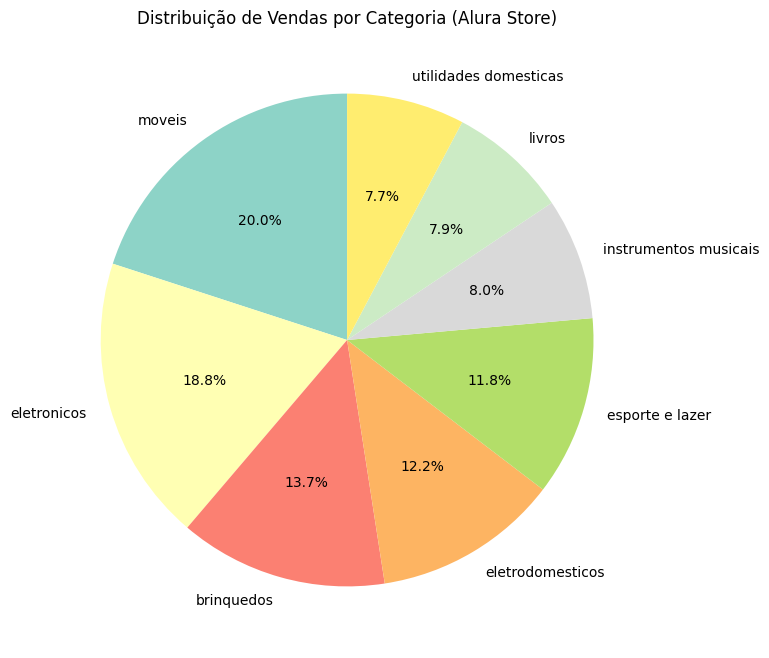

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# juntando todas as lojas em uma tabela
df_todas_lojas = pd.concat([loja, loja2, loja3, loja4])

# contando as categorias no geral
categorias_geral = df_todas_lojas['Categoria do Produto'].value_counts()

# gráfico de pizza para vendas
plt.figure(figsize=(8, 8))
categorias_geral.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title('Distribuição de Vendas por Categoria (Alura Store)')
plt.ylabel('') # o rótulo do eixo Y não aparece
plt.show()

# 3. Média de Avaliação das Lojas


In [5]:
print("⭐ === Média de Avaliações dos Clientes ===\n")

# dicionário para guardar médias
medias_avaliacoes = {}

for nome, df in lista_lojas:
    # calculo de média aritmética de todos os números da coluna
    media = df['Avaliação da compra'].mean()

    medias_avaliacoes[nome] = media

    print(f"- {nome}: {media:.2f} estrelas\n")

⭐ === Média de Avaliações dos Clientes ===

- Loja 1: 3.98 estrelas

- Loja 2: 4.04 estrelas

- Loja 3: 4.05 estrelas

- Loja 4: 4.00 estrelas



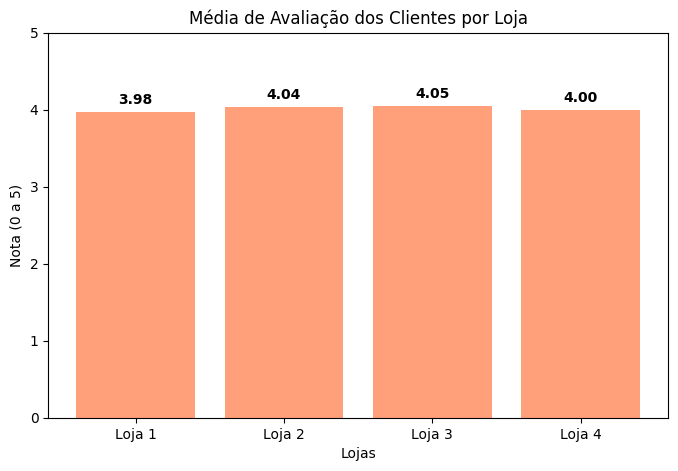

In [6]:
import matplotlib.pyplot as plt

nomes_lojas = list(medias_avaliacoes.keys())
notas = list(medias_avaliacoes.values())

# gráfico de barras
plt.figure(figsize=(8, 5))

plt.bar(nomes_lojas, notas, color='#FFA07A')
plt.ylim(0, 5) # eixo Y com limite de 0 a 5

plt.title('Média de Avaliação dos Clientes por Loja')
plt.ylabel('Nota (0 a 5)')
plt.xlabel('Lojas')

# colocando o valor exato em cima de cada barra
for i, nota in enumerate(notas):
    plt.text(i, nota + 0.1, f'{nota:.2f}', ha='center', fontweight='bold')

plt.show()


# 4. Produtos Mais e Menos Vendidos

In [7]:
nome_coluna_produto = 'Produto'

dados_produtos = {}

for nome, df in lista_lojas:
    # contagem de vezes de cada produto vendido (do maior para o menor)
    vendas_produto = df[nome_coluna_produto].value_counts()

    # destacar os 5 mais vendidos (head()) e os 5 menos vendidos (tail())
    mais_vendidos = vendas_produto.head(5)
    menos_vendidos = vendas_produto.tail(5)

    dados_produtos[nome] = {
        'mais_vendidos': mais_vendidos,
        'menos_vendidos': menos_vendidos
    }

    print(f"\n{'='*15} {nome} {'='*15}\n")
    print(f"🟢 TOP 5 MAIS VENDIDOS:\n{mais_vendidos.to_string()}\n")
    print(f"🔴 TOP 5 MENOS VENDIDOS:\n{menos_vendidos.to_string()}\n")


=============== Loja 1 ===============

🟢 TOP 5 MAIS VENDIDOS:
Produto
Micro-ondas           60
TV Led UHD 4K         60
Guarda roupas         60
Secadora de roupas    58
Cômoda                56

🔴 TOP 5 MENOS VENDIDOS:
Produto
Ciência de dados com python    39
Pandeiro                       36
Panela de pressão              35
Headset                        33
Celular ABXY                   33


=============== Loja 2 ===============

🟢 TOP 5 MAIS VENDIDOS:
Produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Violão                      58
Pandeiro                    58

🔴 TOP 5 MENOS VENDIDOS:
Produto
Fone de ouvido       37
Poltrona             35
Mesa de jantar       34
Impressora           34
Jogo de tabuleiro    32


=============== Loja 3 ===============

🟢 TOP 5 MAIS VENDIDOS:
Produto
Kit banquetas      57
Mesa de jantar     56
Cama king          56
Jogo de panelas    55
Cômoda             55

🔴 TOP 5 MENOS VENDIDOS:
Produto
Gui

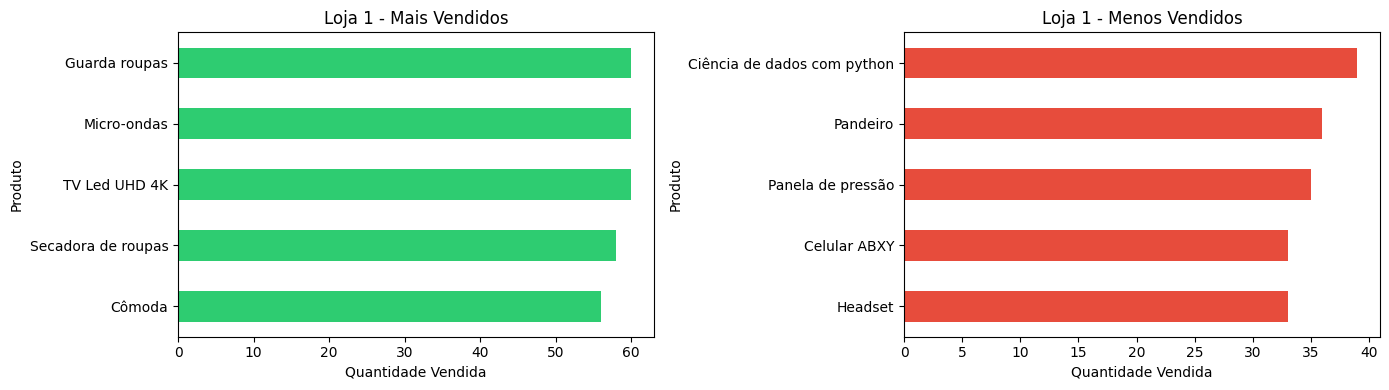

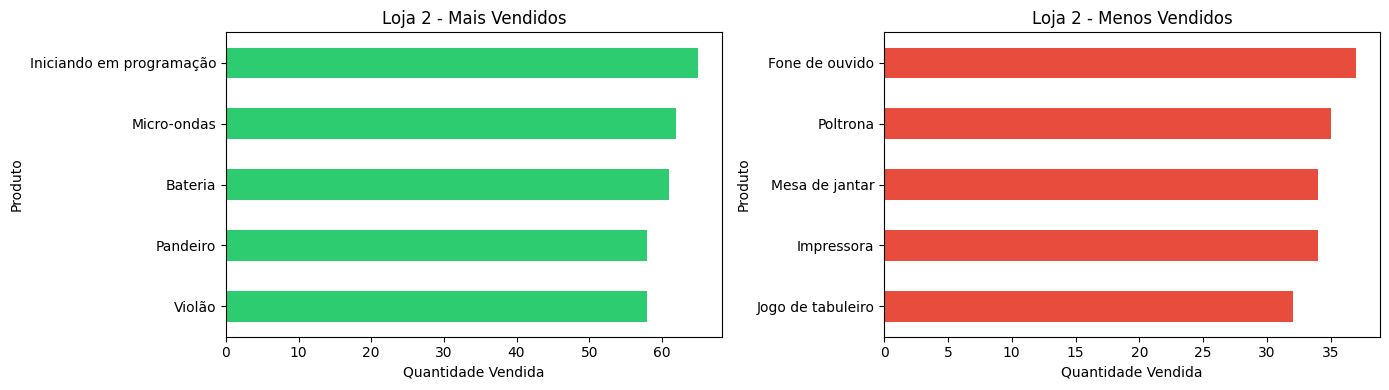

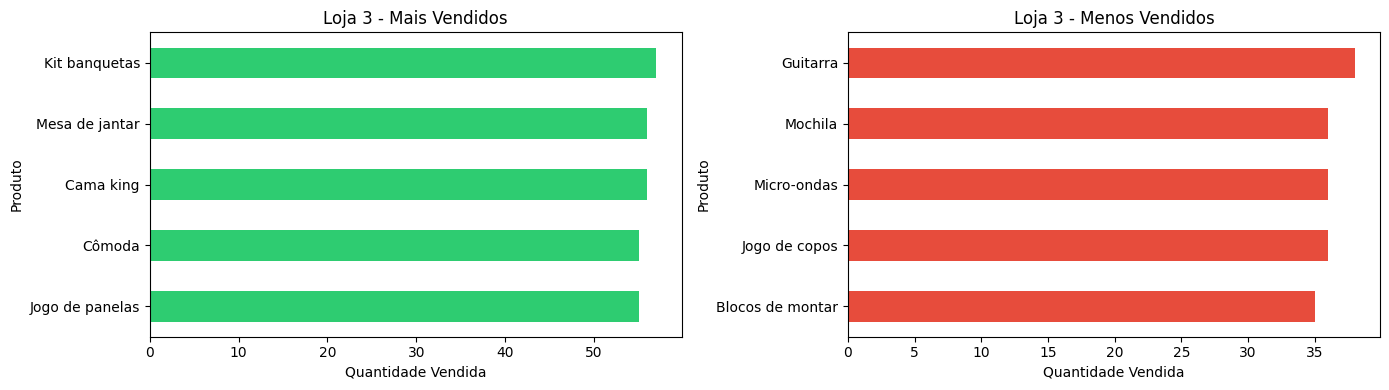

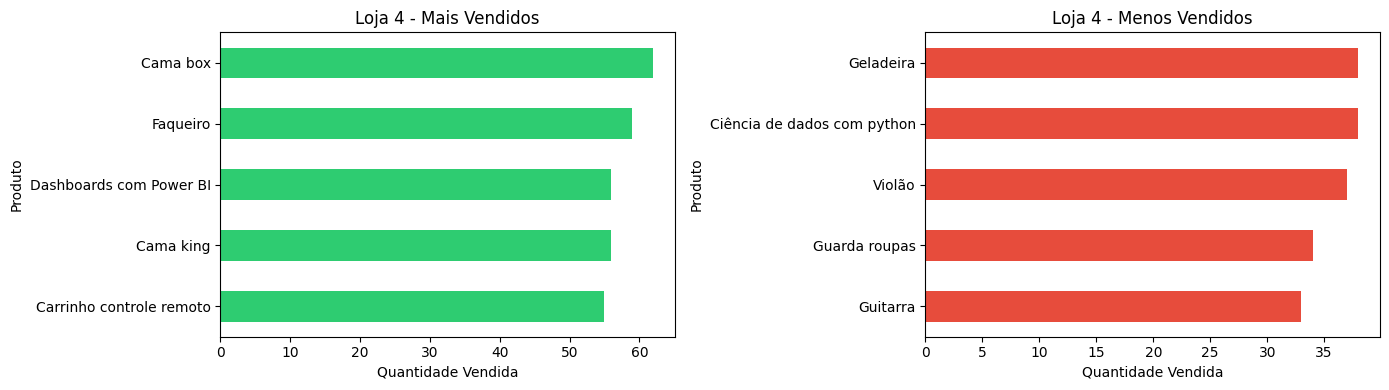

In [8]:
import matplotlib.pyplot as plt

for nome, dados in dados_produtos.items():

    # dados da loja
    mais_vendidos = dados['mais_vendidos']
    menos_vendidos = dados['menos_vendidos']

    # criando 2 gráficos lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # gráfico 1: mais vendidos (verde)
    mais_vendidos.sort_values().plot(kind='barh', color='#2ECC71', ax=ax1)
    ax1.set_title(f'{nome} - Mais Vendidos')
    ax1.set_xlabel('Quantidade Vendida')

    # gráfico 2: menos vendidos (vermelho)
    menos_vendidos.sort_values().plot(kind='barh', color='#E74C3C', ax=ax2)
    ax2.set_title(f'{nome} - Menos Vendidos')
    ax2.set_xlabel('Quantidade Vendida')

    plt.tight_layout()
    plt.show()

# 5. Frete Médio por Loja

In [9]:
nome_coluna_frete = 'Frete'

medias_frete = {}

print("🚚 === Custo Médio de Frete por Loja ===\n")

for nome, df in lista_lojas:
    # calculo da médiqa do frete
    frete_medio = df[nome_coluna_frete].mean()

    medias_frete[nome] = frete_medio

    print(f"- {nome}: R$ {frete_medio:.2f}\n")

🚚 === Custo Médio de Frete por Loja ===

- Loja 1: R$ 34.69

- Loja 2: R$ 33.62

- Loja 3: R$ 33.07

- Loja 4: R$ 31.28



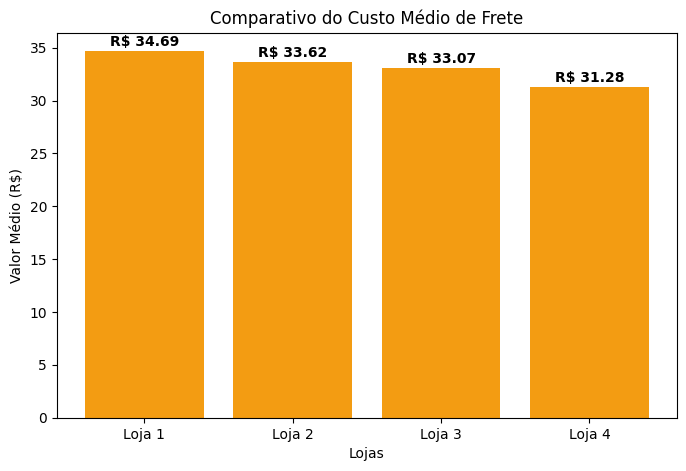

In [10]:
import matplotlib.pyplot as plt

nomes_lojas = list(medias_frete.keys())
valores_frete = list(medias_frete.values())

plt.figure(figsize=(8, 5))

bars = plt.bar(nomes_lojas, valores_frete, color='#F39C12')

plt.title('Comparativo do Custo Médio de Frete')
plt.ylabel('Valor Médio (R$)')
plt.xlabel('Lojas')

# colocando o valor exato em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'R$ {yval:.2f}', ha='center', fontweight='bold')

plt.show()

# Análise de Desempenho Geográfico

In [13]:
#código a ser revisado
import folium
from folium.plugins import HeatMap
import pandas as pd

print("🗺️ Mapa de Calor de Vendas")

# pegando as tabelas de dentro de lista_lojas
dataframes_das_lojas = [df for nome, df in lista_lojas]

df_todas_lojas = pd.concat(dataframes_das_lojas)

# tirando linhas com dados faltando (dropna)
coordenadas = df_todas_lojas[['lat', 'lon']].dropna().values.tolist()

mapa_vendas = folium.Map(location=[-15.7801, -47.9292], zoom_start=4, tiles='cartodbpositron')

HeatMap(coordenadas, radius=15, blur=10, max_zoom=1).add_to(mapa_vendas)

mapa_vendas

🗺️ Mapa de Calor de Vendas


# Relatório Final

# 📊 Relatório Final: Análise de Desempenho e Eficiência da Alura Store

## 1. Introdução
Este relatório apresenta uma análise detalhada dos indicadores de desempenho de quatro lojas da rede Alura Store. O objetivo principal desta investigação é fornecer embasamento analítico para apoiar o Senhor João na decisão estratégica de **qual loja deve ser vendida** para financiar seu novo empreendimento.

A metodologia de análise baseou-se no levantamento e cruzamento de dados cruciais para o varejo: faturamento total, volume de vendas por categoria, giro de estoque (produtos mais e menos vendidos), satisfação do cliente (avaliações médias) e impacto do custo logístico (frete médio).

---

## 2. Desenvolvimento: Apresentação e Análise dos Dados

Através do processamento dos arquivos disponibilizados, consolidamos o seguinte panorama operacional da rede:

### 💰 2.1. Faturamento Total
O faturamento é o principal indicador de volume de negócios. A análise revelou uma disparidade significativa entre a líder e a última colocada:
* **Loja 1:** R$ 1.534.509,12 (Melhor desempenho)

* **Loja 2:** R$ 1.488.459,06

* **Loja 3:** R$ 1.464.025,03

* **Loja 4:** R$ 1.384.497,58 (Pior desempenho)

*Observação: A Loja 4 arrecadou aproximadamente R$ 150 mil a menos que a Loja 1.*

### 📦 2.2. Comportamento de Categorias e Produtos
O perfil de consumo é padronizado em toda a rede. As categorias **Móveis** e **Eletrônicos** são os produtos de maiores vendas absolutas em todas as unidades.
Entretanto, ao analisar os produtos individualmente, notamos gargalos específicos:
* A **Loja 1** tem excelente saída de eletrodomésticos de alto valor (Micro-ondas, TV 4K).
* A **Loja 4**, apesar de vender bem itens de menor valor agregado (Cama box, Faqueiro), possui extrema dificuldade em dar saída a produtos premium, tendo a *Geladeira* e o *Guarda-roupas* entre seus itens menos vendidos.

### ⭐ 2.3. Satisfação do Cliente e Custo Logístico (Frete)
Sabendo que o frete é pago pelo cliente, cruzamos essas duas métricas para entender a eficiência operacional:
* **Loja 1:** Possui o frete mais caro da rede (R$ 34,69). Como consequência direta, reflete a pior média de satisfação dos clientes (3.98 estrelas).

* **Loja 3:** Apresenta o melhor equilíbrio, com a maior nota de avaliação da rede (4.05 estrelas) e um frete intermediário (R$ 33,07).

* **Loja 4:** Possui o frete mais barato para o cliente (R$ 31,28) e mantém uma boa avaliação (4.00 estrelas).

---

## 3. Conclusão e Recomendação Estratégica

Com base na correlação de todos os fatores analisados e nas visualizações geradas, a recomendação final para o Senhor João é a **venda da Loja 4**.

**Justificativa da Decisão:**
A decião final está relacionada a **baixa eficiência de conversão** desta unidade. No varejo, um custo logístico baixo (frete barato) e boas avaliações são os principais atrativos para alavancar vendas. A **Loja 4** possui o cenário ideal (o frete mais barato da rede e nota 4.00), mas **falha drasticamente em converter essa vantagem em receita**.

Seu faturamento é o pior da rede (R$ 1.384.497,58) e a loja apresenta dificuldade crônica em vender produtos de alto valor agregado (como geladeiras).

Enquanto a Loja 1 fatura alto mesmo com problemas logísticos (frete caro), a Loja 4 prova ser o elo menos produtivo e escalável da operação. Vender a Loja 4 permitirá ao Senhor João levantar o capital necessário para o seu novo empreendimento sem comprometer o forte fluxo de caixa gerado pelas outras três unidades.

Para consolidar esta recomendação, o grafico abaixo aprenseta uma matriz de eficiência que cruza o faturamento total com o custo de frete das quatro lojas. Essa visualização corrobora a decisão de venda ao evidenciar visualmente o baixo desempenho financeiro da Loja 4, mesmo operando com os menores custos logísticos da rede.

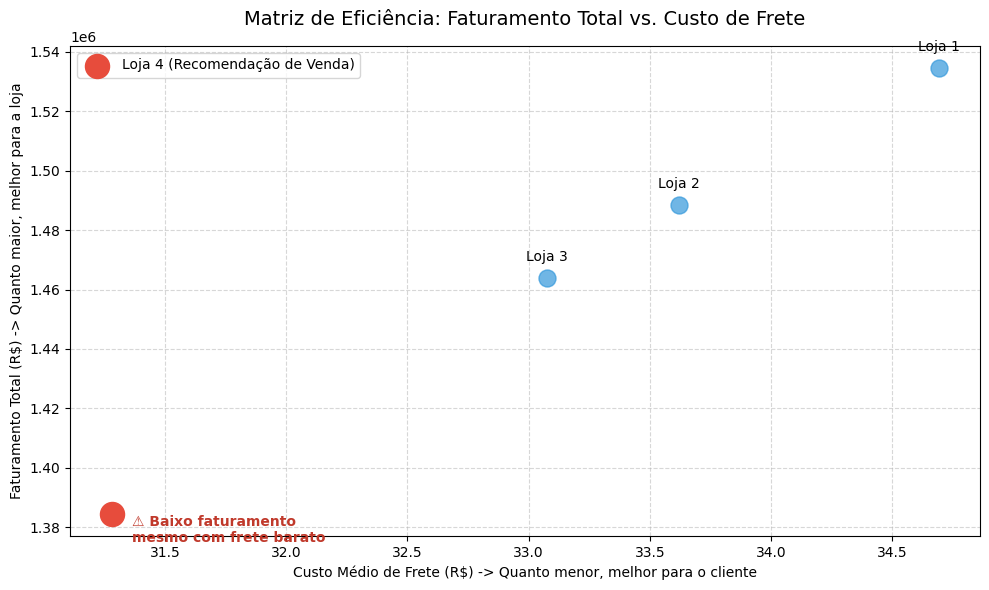

In [11]:
# conclusão analítica: cruzamento de faturamento x frete
import matplotlib.pyplot as plt

# listas anteriores
nomes = list(faturamentos.keys())
valores_fat = list(faturamentos.values())
valores_frete = list(medias_frete.values())

plt.figure(figsize=(10, 6))

# gráfico de dispersão ponto a ponto
for i in range(len(nomes)):
    loja = nomes[i]
    x = valores_frete[i]
    y = valores_fat[i]

    # destaque para a loja 4
    if loja == 'Loja 4':
        plt.scatter(x, y, color='#E74C3C', s=300, label='Loja 4 (Recomendação de Venda)', zorder=5)

        plt.annotate('⚠️ Baixo faturamento\nmesmo com frete barato',
                     (x, y), xytext=(15, -20), textcoords='offset points',
                     color='#C0392B', weight='bold')

    else:
        plt.scatter(x, y, color='#3498DB', s=150, alpha=0.7)
        plt.annotate(loja, (x, y), xytext=(0, 12), textcoords='offset points', ha='center')


plt.title('Matriz de Eficiência: Faturamento Total vs. Custo de Frete', fontsize=14, pad=15)
plt.xlabel('Custo Médio de Frete (R$) -> Quanto menor, melhor para o cliente')
plt.ylabel('Faturamento Total (R$) -> Quanto maior, melhor para a loja')


plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()